# Generating MNIST-Like Digits with a GAN

In this project, we will build a **Generative Adversarial Network (GAN)** capable of generating images similar to handwritten digits from the MNIST dataset.

A GAN consists of two neural networks that compete with each other:

* **Generator** – takes random noise as input and learns to generate realistic-looking handwritten digits.
* **Discriminator** – receives an image and learns to distinguish between real MNIST images and images generated by the Generator.

During training, the Generator gradually improves at producing convincing fake digits, while the Discriminator improves at detecting them. This competition allows the Generator to eventually learn the underlying distribution of the MNIST dataset and generate new digit-like images.

The project will proceed step by step:

1. Load and preprocess the MNIST dataset.
2. Build the Generator.
3. Build the Discriminator.
4. Define the GAN training process.
5. Train the two networks.
6. Generate and visualize new handwritten digits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Reshape, BatchNormalization
from tensorflow.keras.layers import LeakyReLU, Conv2DTranspose
from tensorflow.keras.layers import Conv2D, Flatten, Dropout

from tensorflow.keras.optimizers import Adam

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"


2026-09-07 16:48:51.832588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-07 16:48:51.850168: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-07 16:48:51.855530: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-07 16:48:51.869256: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.17.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1788799733.335345  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1788799733.345027  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1788799733.347631  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [3]:
######################################################################
# STEP 1: LOAD AND PREPROCESS THE MNIST DATASET
######################################################################

# Load the MNIST dataset
(x_train, _), (_, _) = mnist.load_data()

# Use only 10,000 images while developing the GAN
x_train = x_train[:10000]

# Check the original shape and pixel range
print("Original shape:", x_train.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

# Normalize pixel values from [0, 255] to [-1, 1]
x_train = x_train.astype("float32") / 127.5 - 1

# Add a channel dimension
x_train = np.expand_dims(x_train, axis=-1)

# Check the processed shape and pixel range
print("\nProcessed shape:", x_train.shape)
print("Pixel value range:", x_train.min(), "to", x_train.max())

Original shape: (10000, 28, 28)
Pixel value range: 0 to 255

Processed shape: (10000, 28, 28, 1)
Pixel value range: -1.0 to 1.0


In [4]:
######################################################################
# STEP 2: BUILD THE GENERATOR
######################################################################

# Create the Generator model
generator = Sequential(name="Generator")

# Define the input shape
generator.add(Input(shape=(100,)))

# Start from a random noise vector
generator.add(Dense(7 * 7 * 128))
generator.add(BatchNormalization())
generator.add(LeakyReLU(alpha=0.2))

# Reshape into a small feature map
generator.add(Reshape((7, 7, 128)))

# Upsample from 7x7 to 14x14
generator.add(Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"))
generator.add(BatchNormalization())
generator.add(LeakyReLU(alpha=0.2))

# Upsample from 14x14 to 28x28
generator.add(Conv2DTranspose(64, kernel_size=4, strides=2, padding="same"))
generator.add(BatchNormalization())
generator.add(LeakyReLU(alpha=0.2))

# Generate the final 28x28 grayscale image
generator.add(Conv2DTranspose(1, kernel_size=3, padding="same", activation="tanh"))

generator.summary()

I0000 00:00:1788799733.586180  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1788799733.590383  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1788799733.599857  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1788799733.750597  112891 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           577 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,053,313 (4.02 MB)

 Trainable params: 1,040,385 (3.97 MB)

 Non-trainable params: 12,928 (50.50 KB)

In [5]:
######################################################################
# STEP 3: BUILD AND COMPILE THE DISCRIMINATOR
######################################################################

# Create the discriminator model
discriminator = Sequential(name="Discriminator")

# Define the input shape
discriminator.add(Input(shape=(28, 28, 1)))

# First convolutional layer
discriminator.add(Conv2D(64, kernel_size=3, strides=2, padding="same"))
discriminator.add(LeakyReLU(alpha=0.2))
discriminator.add(Dropout(0.3))

# Second convolutional layer
discriminator.add(Conv2D(128, kernel_size=3, strides=2, padding="same"))
discriminator.add(LeakyReLU(alpha=0.2))
discriminator.add(Dropout(0.3))

# Flatten the feature maps
discriminator.add(Flatten())

# Output: probability that the image is real
discriminator.add(Dense(1, activation="sigmoid"))

discriminator.summary()

# Define the optimizer
optimizer = Adam(learning_rate=0.0002, beta_1=0.5)

# Compile the discriminator
discriminator.compile(
    loss="binary_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"],
    run_eagerly=True
)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,769 (315.50 KB)

 Trainable params: 80,769 (315.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
######################################################################
# STEP 4: BUILD THE GAN
######################################################################


# Freeze the discriminator when training the combined GAN
discriminator.trainable = False

# Create the combined GAN
gan = Sequential(name="GAN")

# Input: random noise vector
gan.add(Input(shape=(100,)))

# Generator produces a fake image
gan.add(generator)

# Discriminator evaluates the generated image
gan.add(discriminator)

# Compile the combined GAN
gan.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    run_eagerly=True ## attempt to fix a memory leak
)

gan.summary()

Model: "GAN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Generator (Sequential)          │ (None, 28, 28, 1)      │     1,053,313 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Discriminator (Sequential)      │ (None, 1)              │        80,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,134,082 (4.33 MB)

 Trainable params: 1,040,385 (3.97 MB)

 Non-trainable params: 93,697 (366.00 KB)

In [11]:
######################################################################
# STEP 5: TRAIN THE GAN
######################################################################

# Training parameters
epochs = 20
batch_size = 128
half_batch = batch_size // 2

# Number of batches per epoch
batches_per_epoch = x_train.shape[0] // batch_size

for epoch in range(epochs):

    for batch in range(batches_per_epoch):

        # --------------------------------------------------------------
        # 1. TRAIN THE DISCRIMINATOR
        # --------------------------------------------------------------

        # Select a random batch of real MNIST images
        idx = np.random.randint(0, x_train.shape[0], half_batch)
        real_images = x_train[idx]

        # Generate random noise
        noise = np.random.normal(0, 1, (half_batch, 100))

        # Generate fake images
        fake_images = generator.predict(noise, verbose=0)

        # Labels for real and fake images
        real_labels = np.ones((half_batch, 1))
        fake_labels = np.zeros((half_batch, 1))

        # Trainable
        discriminator.trainable = True
        
        # Train on real images
        d_loss_real = discriminator.train_on_batch(
            real_images, real_labels
        )

        # Train on fake images
        d_loss_fake = discriminator.train_on_batch(
            fake_images, fake_labels
        )

        # Average the two discriminator losses
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # --------------------------------------------------------------
        # 2. TRAIN THE GENERATOR
        # --------------------------------------------------------------

        # Non-Trainable discriminator
        discriminator.trainable = False

        # Generate a new batch of random noise
        noise = np.random.normal(0, 1, (batch_size, 100))

        # We want the discriminator to classify generated images as real
        valid_labels = np.ones((batch_size, 1))

        # Train the combined GAN
        g_loss = gan.train_on_batch(
            noise, valid_labels
        )
        
        # Print progress after each epoch
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"D loss: {d_loss[0]:.4f} | "
            f"D accuracy: {100 * d_loss[1]:.2f}% | "
            f"G loss: {g_loss[0]:.4f}"
        )


Epoch 1/20 | D loss: 0.6573 | D accuracy: 55.36% | G loss: 0.6573
Epoch 1/20 | D loss: 0.6573 | D accuracy: 55.36% | G loss: 0.6573
Epoch 1/20 | D loss: 0.6573 | D accuracy: 55.36% | G loss: 0.6573
Epoch 1/20 | D loss: 0.6573 | D accuracy: 55.36% | G loss: 0.6573
Epoch 1/20 | D loss: 0.6573 | D accuracy: 55.37% | G loss: 0.6573
Epoch 1/20 | D loss: 0.6573 | D accuracy: 55.37% | G loss: 0.6573
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20 | D loss: 0.6574 | D accuracy: 55.36% | G loss: 0.6574
Epoch 1/20

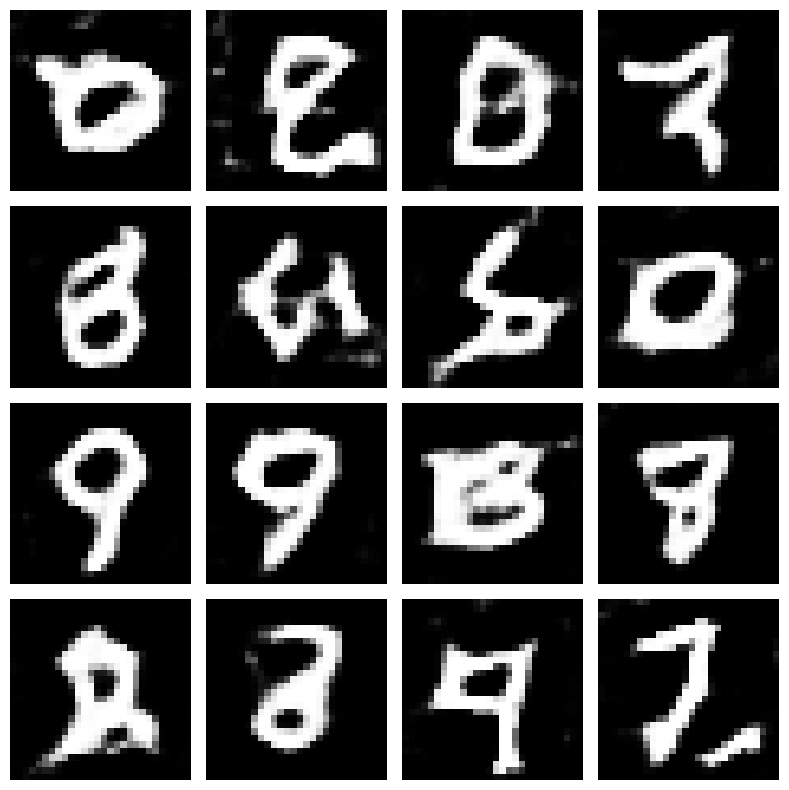

In [17]:
######################################################################
# STEP 6: GENERATE AND VISUALIZE NEW HANDWRITTEN DIGITS
######################################################################

# Generate random noise vectors
noise = np.random.normal(0, 1, (16, 100))

# Generate 16 new images
generated_images = generator(noise, training=False).numpy()

# Rescale pixel values from [-1, 1] back to [0, 1]
generated_images = (generated_images + 1) / 2

# Display the generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated_images[i, :, :, 0], cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
######################################################################
# STEP 7: SAVE THE TRAINED GAN MODELS
######################################################################

import os

# Create the models directory if it does not already exist
os.makedirs("../models", exist_ok=True)

# Save the three models
gan.save("../models/gan_mnist.keras")
generator.save("../models/generator_gan_mnist.keras")
discriminator.save("../models/discriminator_gan_mnist.keras")

print("Models saved successfully:")
print("../models/gan_mnist.keras")
print("../models/generator_gan_mnist.keras")
print("../models/discriminator_gan_mnist.keras")



Models saved successfully:
../models/gan_mnist.keras
../models/generator_gan_mnist.keras
../models/discriminator_gan_mnist.keras
